In [9]:
!nvidia-smi

Fri May  1 03:50:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P0             27W /   70W |       0MiB /  15360MiB |      6%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!mkdir -p data/input
!mkdir -p data/output

In [15]:
import os
import urllib.request

os.makedirs("data/input", exist_ok=True)

for i in range(1, 101):
    url = "https://picsum.photos/256/256"
    path = f"data/input/img_{i}.jpg"
    urllib.request.urlretrieve(url, path)

print("Downloaded 100 images")

Downloaded 100 images


In [21]:
!rm -f final_results.csv
!make clean
!make


rm -f pipeline
nvcc -std=c++17 src/main.cu src/streams.cu -o pipeline
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
src/stb_image.h(4276): warning #550-D: variable "old_limit" was set but never used
     unsigned int cur, limit, old_limit;
                              ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

src/stb_image.h(5185): warning #550-D: variable "idata_limit_old" was set but never used
                 stbi__uint32 idata_limit_old = idata_limit;
                              ^

src/stb_image.h(6972): warning #550-D: variable "out_size" was set but never used
        int out_size = 0;
            ^

src/stb_image.h(6973): warning #550-D: variable "delays_size" was set but never used
        int delays_size = 0;
            ^



In [22]:
!./pipeline data/input data/output
!head final_results.csv

Processed: data/input/img_15.jpg | CPU(ms): 0.378871 | GPU(ms): 0.214816
Processed: data/input/img_2.jpg | CPU(ms): 0.365735 | GPU(ms): 0.024128
Processed: data/input/img_88.jpg | CPU(ms): 0.536738 | GPU(ms): 0.016224
Processed: data/input/img_35.jpg | CPU(ms): 0.370137 | GPU(ms): 0.045056
Processed: data/input/img_44.jpg | CPU(ms): 0.373218 | GPU(ms): 0.021472
Processed: data/input/img_37.jpg | CPU(ms): 0.626855 | GPU(ms): 0.018304
Processed: data/input/img_56.jpg | CPU(ms): 0.366349 | GPU(ms): 0.020288
Processed: data/input/img_99.jpg | CPU(ms): 0.375328 | GPU(ms): 0.019264
Processed: data/input/img_28.jpg | CPU(ms): 0.407067 | GPU(ms): 0.019008
Processed: data/input/img_42.jpg | CPU(ms): 0.376935 | GPU(ms): 0.019904
Processed: data/input/img_3.jpg | CPU(ms): 0.420254 | GPU(ms): 0.022208
Processed: data/input/img_62.jpg | CPU(ms): 0.615286 | GPU(ms): 0.017728
Processed: data/input/img_23.jpg | CPU(ms): 0.658624 | GPU(ms): 0.02192
Processed: data/input/img_17.jpg | CPU(ms): 0.401246 |

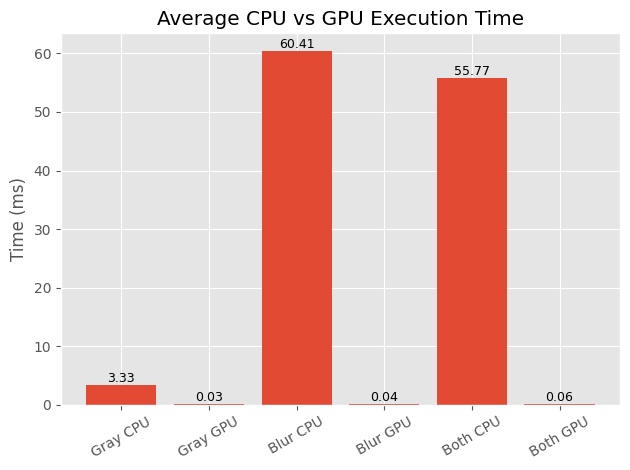

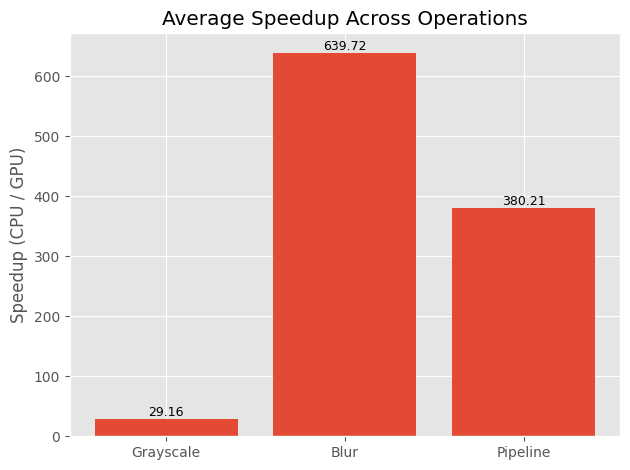

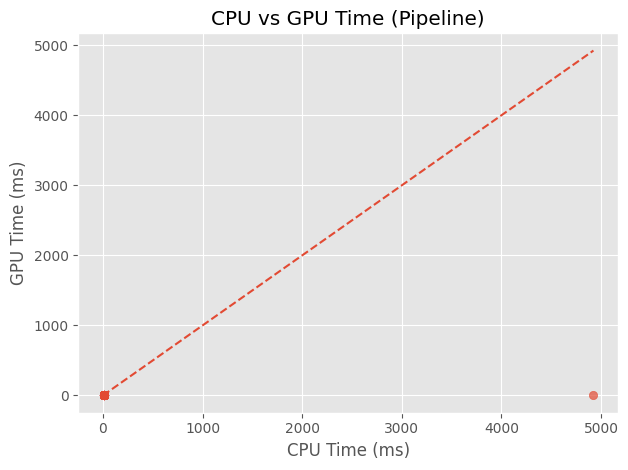

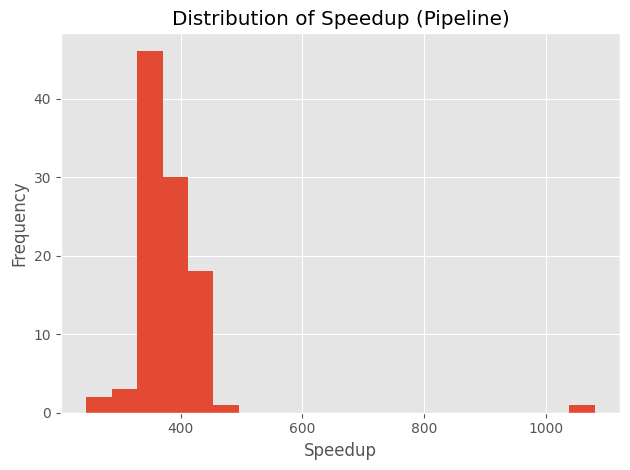

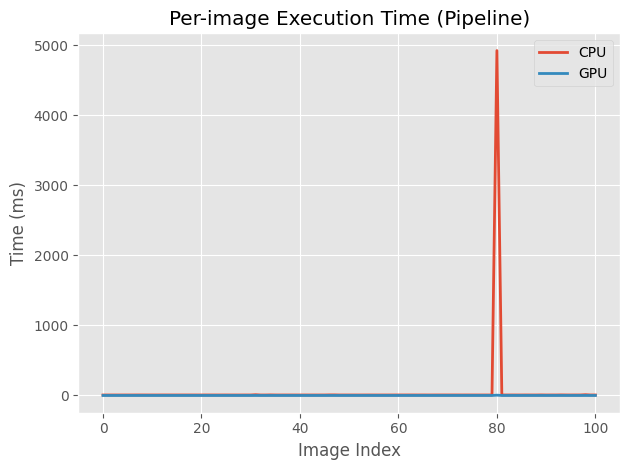


===== SUMMARY =====
Avg Gray Speedup: 29.16x
Avg Blur Speedup: 639.72x
Avg Pipeline Speedup: 380.21x


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# I am loading the CSV
df = pd.read_csv("final_results.csv")

# I am computing speedups
df["gray_speedup"] = df["gray_cpu"] / df["gray_gpu"]
df["blur_speedup"] = df["blur_cpu"] / df["blur_gpu"]
df["both_speedup"] = df["both_cpu"] / df["both_gpu"]

os.makedirs("plots", exist_ok=True)

# I am using a clean style
plt.style.use('ggplot')

def save_and_show(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=300)
    plt.show()
    plt.close(fig)

def annotate_bars(ax, values):
    # I am annotating bars with values
    for i, v in enumerate(values):
        ax.text(i, v, f"{v:.2f}", ha='center', va='bottom', fontsize=9)

# ------------------------------
# 1. Average Time Comparison
# ------------------------------
fig, ax = plt.subplots()

avg_times = [
    df["gray_cpu"].mean(), df["gray_gpu"].mean(),
    df["blur_cpu"].mean(), df["blur_gpu"].mean(),
    df["both_cpu"].mean(), df["both_gpu"].mean()
]

labels = [
    "Gray CPU", "Gray GPU",
    "Blur CPU", "Blur GPU",
    "Both CPU", "Both GPU"
]

ax.bar(labels, avg_times)
ax.set_ylabel("Time (ms)")
ax.set_title("Average CPU vs GPU Execution Time")
ax.tick_params(axis='x', rotation=30)

annotate_bars(ax, avg_times)

save_and_show(fig, "plots/avg_time_comparison.png")

# ------------------------------
# 2. Speedup Comparison
# ------------------------------
fig, ax = plt.subplots()

avg_speedups = [
    df["gray_speedup"].mean(),
    df["blur_speedup"].mean(),
    df["both_speedup"].mean()
]

labels = ["Grayscale", "Blur", "Pipeline"]

bars = ax.bar(labels, avg_speedups)

ax.set_ylabel("Speedup (CPU / GPU)")
ax.set_title("Average Speedup Across Operations")

annotate_bars(ax, avg_speedups)

save_and_show(fig, "plots/speedup_comparison.png")

# ------------------------------
# 3. CPU vs GPU Scatter (with diagonal)
# ------------------------------
fig, ax = plt.subplots()

ax.scatter(df["both_cpu"], df["both_gpu"], alpha=0.7)

# I am plotting y=x reference line
max_val = max(df["both_cpu"].max(), df["both_gpu"].max())
ax.plot([0, max_val], [0, max_val], linestyle='--')

ax.set_xlabel("CPU Time (ms)")
ax.set_ylabel("GPU Time (ms)")
ax.set_title("CPU vs GPU Time (Pipeline)")

save_and_show(fig, "plots/cpu_vs_gpu_scatter.png")

# ------------------------------
# 4. Speedup Distribution
# ------------------------------
fig, ax = plt.subplots()

ax.hist(df["both_speedup"], bins=20)
ax.set_xlabel("Speedup")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Speedup (Pipeline)")

save_and_show(fig, "plots/speedup_distribution.png")

# ------------------------------
# 5. Per-image Variation
# ------------------------------
fig, ax = plt.subplots()

ax.plot(df["both_cpu"], label="CPU", linewidth=2)
ax.plot(df["both_gpu"], label="GPU", linewidth=2)

ax.set_xlabel("Image Index")
ax.set_ylabel("Time (ms)")
ax.set_title("Per-image Execution Time (Pipeline)")
ax.legend()

save_and_show(fig, "plots/time_variation.png")

# ------------------------------
# 6. Summary
# ------------------------------
print("\n===== SUMMARY =====")
print(f"Avg Gray Speedup: {df['gray_speedup'].mean():.2f}x")
print(f"Avg Blur Speedup: {df['blur_speedup'].mean():.2f}x")
print(f"Avg Pipeline Speedup: {df['both_speedup'].mean():.2f}x")